# E-commerce Customer Retention – Exploratory Data Analysis

Purpose:
- Understand raw data structure
- Identify data quality issues
- Validate assumptions before SQL cohort logic

In [1]:
import os
os.listdir("../data")

['olist_customers_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'README.md']

In [2]:
import pandas as pd

customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

In [3]:
print("customers:",customers.shape)
print("orders:",orders.shape)
print("order_items:",order_items.shape)

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)


In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
# Convert to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"]
)

# Create order_month
orders["order_month"] = (
    orders["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
)
orders[["customer_id", "order_purchase_timestamp", "order_month"]].head(10)


,customer_id,order_purchase_timestamp,order_month
0,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-01
1,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-01
2,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-01
3,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-01
4,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-01
5,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,2017-07-01
6,ed0271e0b7da060a393796590e7b737a,2017-04-11 12:22:08,2017-04-01
7,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,2017-05-01
8,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,2017-01-01
9,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,2017-07-01


In [8]:
#first_purchase = (
#    orders
#    .groupby("customer_id", as_index=False)["order_month"]
#    .min()
#    .rename(columns={"order_month": "cohort_month"})
#)

In [9]:
#first_purchase.head()

In [10]:
#orders_cohort = orders.merge(
#    first_purchase,
#    on="customer_id",
#    how="left"
#)

### ⚠️ Correction Note
Initially, cohort analysis was attempted using customer_id.
In the Olist dataset, customer_id is order-level and changes across purchases.
This caused incorrect cohort ages.

The corrected analysis below uses customer_unique_id to represent real customers.

In [11]:
orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [12]:
orders[[
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_month"
]].head()

,order_id,customer_id,customer_unique_id,order_purchase_timestamp,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-01


In [13]:
first_purchase = (
    orders
    .groupby("customer_unique_id", as_index=False)["order_month"]
    .min()
    .rename(columns={"order_month": "cohort_month"})
)

In [14]:
first_purchase.head()

,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-01


In [15]:
orders_cohort = orders.merge(
    first_purchase,
    on="customer_unique_id",
    how="left"
)

In [16]:
orders_cohort[[
    "customer_unique_id",
    "order_month",
    "cohort_month"
]].head(20)

,customer_unique_id,order_month,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01
1,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01
5,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01
6,36edbb3fb164b1f16485364b6fb04c73,2017-04-01,2017-04-01
7,932afa1e708222e5821dac9cd5db4cae,2017-05-01,2017-05-01
8,39382392765b6dc74812866ee5ee92a7,2017-01-01,2017-01-01
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,2017-07-01


In [17]:
orders_cohort["cohort_age"] = (
    (orders_cohort["order_month"].dt.year - orders_cohort["cohort_month"].dt.year) * 12
    + (orders_cohort["order_month"].dt.month - orders_cohort["cohort_month"].dt.month)
)

In [18]:
orders_cohort.head(20)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,cohort_month,cohort_age
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-01,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-01,af07308b275d755c9edb36a90c618231,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-01,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-01,7c142cf63193a1473d2e66489a9ae977,2017-11-01,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-01,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,2017-07-01,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,2017-04-01,36edbb3fb164b1f16485364b6fb04c73,2017-04-01,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,2017-05-01,932afa1e708222e5821dac9cd5db4cae,2017-05-01,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,2017-01-01,39382392765b6dc74812866ee5ee92a7,2017-01-01,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,2017-07-01,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,0


In [19]:
orders_cohort["cohort_age"].unique()[:10]

array([ 1,  0, 20,  6,  5, 10,  3,  9,  4,  2], dtype=int32)

In [20]:
orders_cohort[orders_cohort["cohort_age"] > 0].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,cohort_month,cohort_age
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-01,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,1
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04 00:00:00,2018-06-01,ccafc1c3f270410521c3c6f3b249870f,2016-10-01,20
16,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,2018-01-01,6e26bbeaa107ec34112c64e1ee31c0f5,2017-07-01,6
72,6abaad69b8b349c3a529b4b91ce18e46,f5618502bee8eafdee72fb6955e2ebdf,delivered,2018-02-15 10:33:30,2018-02-15 10:47:59,2018-02-20 14:15:09,2018-02-24 19:15:56,2018-03-07 00:00:00,2018-02-01,fa0ee7ceb94193fb02aa78ce3a55695a,2018-01-01,1
148,95cf9f239f724799131f7ca949209bd9,7251aa758779438faea714941f1051c4,delivered,2018-05-25 08:54:21,2018-05-25 09:16:24,2018-05-28 15:43:00,2018-05-30 15:06:44,2018-06-12 00:00:00,2018-05-01,65ee274b862c5c053367be8a70dbc029,2018-04-01,1


### Cohort Logic Validation
- Cohorts defined using customer_unique_id
- cohort_month = first purchase month
- cohort_age calculated as months since first purchase
- cohort_age > 0 verified

In [21]:
#active customers per cohort age

active_customers = (
    orders_cohort
    .groupby(["cohort_month", "cohort_age"])["customer_unique_id"]
    .nunique()
    .reset_index(name="active_customers")
)

In [22]:
#cohort size baseline

cohort_sizes = (
    orders_cohort
    .loc[orders_cohort["cohort_age"] == 0]
    .groupby("cohort_month")["customer_unique_id"]
    .nunique()
    .reset_index(name="cohort_size")
)

In [23]:
retention = active_customers.merge(
    cohort_sizes,
    on="cohort_month",
    how="left"
)

In [24]:
# retention percentage

retention["retention_pct"] = (
    retention["active_customers"] / retention["cohort_size"] * 100
).round(2)

In [25]:
#sanity check of cohort age 0 percent as 100

retention[retention["cohort_age"] == 0]["retention_pct"].unique()

array([100.])

### Partial Cohort Correction
- recent cohorts haven't complete their full lifecycle
- later cohort_age for these cohorts are not yet observable
- including them would appear as churn imcorrectly
- limmit each cohort to its max observed cohort age

In [26]:
#max age per cohort month
max_cohort_age = ( retention
                  .groupby("cohort_month")["cohort_age"]
                  .max()
                  .reset_index(name ="max_cohort_age")
                  )

In [27]:
#merge this back to retention table
retention_with_max = retention.merge(
    max_cohort_age,
    on = "cohort_month",
    how="left"
)

In [28]:
retention_with_max.head(15)

,cohort_month,cohort_age,active_customers,cohort_size,retention_pct,max_cohort_age
0,2016-09-01,0,4,4,100.00,0
1,2016-10-01,0,321,321,100.00,20
2,2016-10-01,6,1,321,0.31,20
3,2016-10-01,9,1,321,0.31,20
4,2016-10-01,11,1,321,0.31,20
5,2016-10-01,13,1,321,0.31,20
6,2016-10-01,15,1,321,0.31,20
7,2016-10-01,17,1,321,0.31,20
8,2016-10-01,19,2,321,0.62,20
9,2016-10-01,20,2,321,0.62,20


In [29]:
#filter valid rows
retention_with_max = retention_with_max[retention_with_max["cohort_age"] <= retention_with_max["max_cohort_age"]]

In [30]:
retention_with_max.head(15)

,cohort_month,cohort_age,active_customers,cohort_size,retention_pct,max_cohort_age
0,2016-09-01,0,4,4,100.00,0
1,2016-10-01,0,321,321,100.00,20
2,2016-10-01,6,1,321,0.31,20
3,2016-10-01,9,1,321,0.31,20
4,2016-10-01,11,1,321,0.31,20
5,2016-10-01,13,1,321,0.31,20
6,2016-10-01,15,1,321,0.31,20
7,2016-10-01,17,1,321,0.31,20
8,2016-10-01,19,2,321,0.62,20
9,2016-10-01,20,2,321,0.62,20


### Revenue Retention Analysis
- Customer retention shows how many customers returned
- Revenue retention shows how much value returrning users generate.
- Measures total revenue per cohort over time
- Percentage of revenue returned across lifecycle months
- we use sum of revenue instead of count users


In [31]:
#each order can have multiple items in table
#aggregate total revenue per order

order_revenue = (order_items
                 .groupby("order_id")["price"].sum()
                 .reset_index(name = "order_revenue")
                 )

In [32]:
order_revenue.head(10)

,order_id,order_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90
5,00048cc3ae777c65dbb7d2a0634bc1ea,21.90
6,00054e8431b9d7675808bcb819fb4a32,19.90
7,000576fe39319847cbb9d288c5617fa6,810.00
8,0005a1a1728c9d785b8e2b08b904576c,145.95
9,0005f50442cb953dcd1d21e1fb923495,53.99


In [33]:
#revenue needed in mainn table
#attach or merge
orders_cohort = orders_cohort.merge(
    order_revenue,
    on = "order_id",
    how = "left"
)


In [34]:
orders_cohort.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,cohort_month,cohort_age,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-01,7c396fd4830fd04220f754e42b4e5bff,2017-09-01,1,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-01,af07308b275d755c9edb36a90c618231,2018-07-01,0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-01,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-01,7c142cf63193a1473d2e66489a9ae977,2017-11-01,0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-01,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,0,19.90
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,2017-07-01,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,0,147.90
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,2017-04-01,36edbb3fb164b1f16485364b6fb04c73,2017-04-01,0,49.90
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,2017-05-01,932afa1e708222e5821dac9cd5db4cae,2017-05-01,0,59.99
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,2017-01-01,39382392765b6dc74812866ee5ee92a7,2017-01-01,0,19.90
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,2017-07-01,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,0,149.99


In [35]:
#total revenue generated by each cohort at each lifecycle month
revenue = (orders_cohort
           .groupby(["cohort_month","cohort_age"])["order_revenue"]
           .sum()
           .reset_index(name="revenue"))

In [36]:
revenue.head(10)

,cohort_month,cohort_age,revenue
0,2016-09-01,0,267.36
1,2016-10-01,0,49507.66
2,2016-10-01,6,99.99
3,2016-10-01,9,339.00
4,2016-10-01,11,49.00
5,2016-10-01,13,115.20
6,2016-10-01,15,298.60
7,2016-10-01,17,98.00
8,2016-10-01,19,289.28
9,2016-10-01,20,158.39


In [37]:
#total revenue at baseline (month 0)
cohort_revenue = (revenue[revenue["cohort_age"] == 0]
                  .groupby("cohort_month")["revenue"]
                  .sum()
                  .reset_index(name = "cohort_revenue"))

In [38]:
cohort_revenue.head(10)

,cohort_month,cohort_revenue
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-12-01,10.90
3,2017-01-01,120301.97
4,2017-02-01,247178.10
5,2017-03-01,373783.03
6,2017-04-01,357773.88
7,2017-05-01,501691.42
8,2017-06-01,427975.47
9,2017-07-01,489344.34


In [39]:
#merge baseline revenue to main revenue table
revenue_retention = revenue.merge(
    cohort_revenue,
    on = "cohort_month",
    how = "left"
)

In [40]:
#calc revenue retention percentage
revenue_retention["revenue_retention_pct"] =(
    revenue_retention["revenue"] / revenue_retention["cohort_revenue"] * 100
    ).round(2)


In [41]:
#partial cohort correction 
#max cohort age merge to revenue retention
revenue_retention = revenue_retention.merge(
    max_cohort_age,
    on = "cohort_month",
    how = "left"
)

In [42]:
#keep only valid lifecycle periods
revenue_retention = revenue_retention[revenue_retention["cohort_age"] <= revenue_retention["max_cohort_age"]]

revenue_retention.head(10)

,cohort_month,cohort_age,revenue,cohort_revenue,revenue_retention_pct,max_cohort_age
0,2016-09-01,0,267.36,267.36,100.00,0
1,2016-10-01,0,49507.66,49507.66,100.00,20
2,2016-10-01,6,99.99,49507.66,0.20,20
3,2016-10-01,9,339.00,49507.66,0.68,20
4,2016-10-01,11,49.00,49507.66,0.10,20
5,2016-10-01,13,115.20,49507.66,0.23,20
6,2016-10-01,15,298.60,49507.66,0.60,20
7,2016-10-01,17,98.00,49507.66,0.20,20
8,2016-10-01,19,289.28,49507.66,0.58,20
9,2016-10-01,20,158.39,49507.66,0.32,20


### Cohort Heatmap prep
- retention data is currently in long format
- converting to matrix for better comparison
- rows = cohort month
- columns = cohort age

In [43]:
retention_matrix = retention_with_max.pivot(
    index = "cohort_month",
    columns = "cohort_age",
    values = "retention_pct" #customer retention
)

retention_matrix.head(10)

cohort_age,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.31,NaN,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,0.62,0.62
2016-12-01,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,NaN,0.39,0.13,0.79,0.39,0.13,0.13,0.26,0.39,0.13,NaN
2017-02-01,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17,0.17,0.11,0.06,0.06,0.23,NaN,NaN
2017-03-01,100.0,0.49,0.38,0.38,0.34,0.15,0.15,0.30,0.34,0.08,0.38,0.15,0.23,0.11,0.15,0.23,0.08,0.15,NaN,NaN
2017-04-01,100.0,0.60,0.21,0.17,0.34,0.26,0.34,0.30,0.30,0.17,0.26,0.09,0.09,0.04,0.09,0.09,0.21,NaN,NaN,NaN
2017-05-01,100.0,0.50,0.50,0.39,0.31,0.33,0.42,0.17,0.25,0.31,0.25,0.33,0.25,0.03,0.19,0.25,NaN,NaN,NaN,NaN
2017-06-01,100.0,0.48,0.35,0.41,0.25,0.38,0.38,0.22,0.13,0.22,0.32,0.35,0.16,0.13,0.19,NaN,NaN,NaN,NaN,NaN


###  Customer Retention Heatmap
- visual representation of cohort over time
- darker cells indicate higheer retention

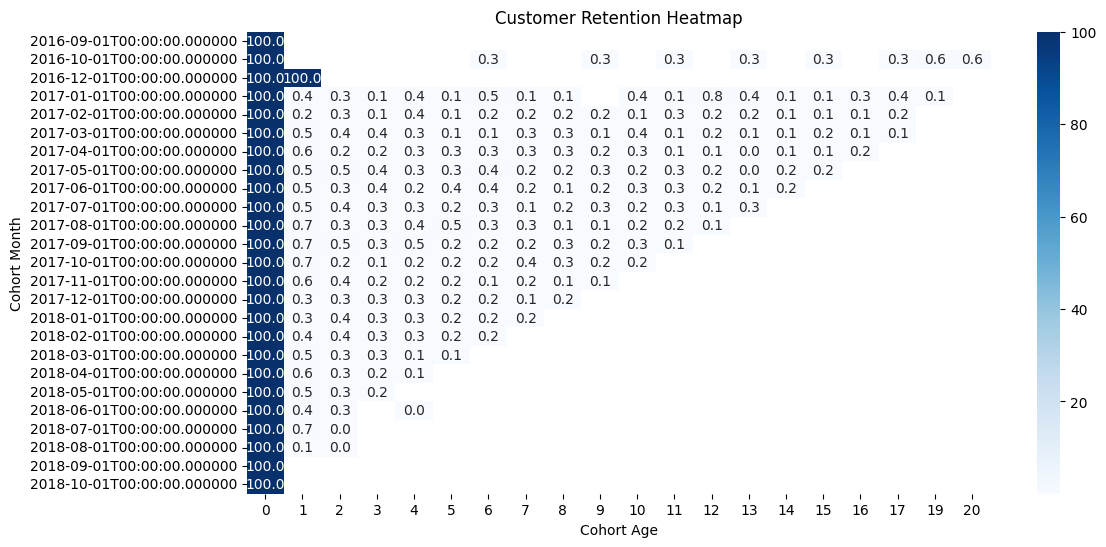

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

#figure size fore readability
plt.figure(figsize=(12,6))

#heatmap for retention matrix
sns.heatmap(
    retention_matrix, #pivot cohort table
    annot = True,     #show value inside cells
    fmt = ".1f",      #format number to 1 decimal place
    cmap = "Blues"    # color scheme (darker = higher retention)
)

#title and labels for clarity
plt.title("Customer Retention Heatmap")
plt.ylabel("Cohort Month")   #rows = cohorts 
plt.xlabel("Cohort Age")     #columns = lifecycle months

plt.show()

## Key Insights
- Retention drops sharply after the first purchase, indicating weak repeat behaviour.
- Most cohorts follow a similar retetion pattern, consistent customer behaviour over time.
- Long term retention is very low, with minimal customer activity beyond initial months.
- Earlier cohorts show slightly high retention due to longer observation periods.